In [1]:
import torch
import torch.nn as nn
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [2]:
# ==========================================
# 1. Génération des données expérimentales
# ==========================================
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    return [dx_dt, dy_dt, dz_dt]

# Paramètres de simulation
dt = 0.03
t_end = 9.0
t_eval = np.arange(0, t_end, dt)
initial_state = [-8.0, 7.0, 27.0]

# Résolution numérique (Vérité terrain)
solution = solve_ivp(lorenz_system, [0, t_end], initial_state, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-10)
t_data = solution.t.reshape(-1, 1)
X_data = solution.y.T  # (N, 3)

# Ajout d'un petit bruit pour simuler des données expérimentales
noise_level = 0.5
X_data += noise_level * np.random.randn(*X_data.shape)

# --- NORMALISATION DES DONNÉES ---
# Normaliser le temps à [0, 1]
t_min, t_max = t_data.min(), t_data.max()
t_norm = (t_data - t_min) / (t_max - t_min)

# Normaliser les états (moyenne=0, std=1)
X_mean = X_data.mean(axis=0, keepdims=True)
X_std = X_data.std(axis=0, keepdims=True)
X_norm = (X_data - X_mean) / X_std

# Facteur d'échelle temporel pour corriger les dérivées : d(X_norm)/d(t_norm) = (t_max-t_min)/X_std * dX/dt
time_scale = (t_max - t_min)  # dt_norm = dt / time_scale

# Conversion en tenseurs PyTorch (données complètes pour la visu)
t_tensor = torch.tensor(t_norm, dtype=torch.float32)
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
X_mean_t = torch.tensor(X_mean, dtype=torch.float32)
X_std_t = torch.tensor(X_std, dtype=torch.float32)

# ==========================================
# Points d'entraînement selon DeepXDE :
#   Tf : 400 points aléatoires uniformes (residual / physics)
#   Ti : 50 points équirépartis (données / conditions initiales)
# ==========================================

# --- Ti : 50 points équirépartis dans le domaine temporel normalisé ---
N_i = 50
ti_indices = np.linspace(0, len(t_norm) - 1, N_i, dtype=int)
t_Ti = torch.tensor(t_norm[ti_indices], dtype=torch.float32)
X_Ti = torch.tensor(X_norm[ti_indices], dtype=torch.float32)
print(f"Ti (données)  : {t_Ti.shape[0]} points équirépartis dans [0, 1]")

# --- Tf : 400 points aléatoires uniformes dans [0, 1] (collocation) ---
N_f = 400
t_Tf = torch.rand(N_f, 1, dtype=torch.float32)  # U(0, 1)
print(f"Tf (résidus)  : {t_Tf.shape[0]} points aléatoires uniformes dans [0, 1]")


Ti (données)  : 50 points équirépartis dans [0, 1]
Tf (résidus)  : 400 points aléatoires uniformes dans [0, 1]


In [3]:
# ==========================================
# 2. Définition de l'architecture du PINN
# ==========================================
class LorenzPINN(nn.Module):
    def __init__(self):
        super(LorenzPINN, self).__init__()
        
        # Réseau de neurones : t_norm -> [X_norm, Y_norm, Z_norm]
        # 4 couches cachées de 32 neurones (plus de capacité)
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 3)
        )
        
        # Initialisation Xavier
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        
        # Paramètres physiques à découvrir — initialisation plus proche
        self.log_sigma = nn.Parameter(torch.tensor(np.log(8.0)))   # init σ=8  (vrai=10)
        self.log_rho   = nn.Parameter(torch.tensor(np.log(20.0)))  # init ρ=20 (vrai=28)
        self.log_beta  = nn.Parameter(torch.tensor(np.log(2.0)))   # init β=2  (vrai=2.67)
    
    @property
    def sigma(self):
        return torch.exp(self.log_sigma)
    
    @property
    def rho(self):
        return torch.exp(self.log_rho)
    
    @property
    def beta(self):
        return torch.exp(self.log_beta)

    def forward(self, t):
        return self.net(t)

    def physics_residuals(self, t, X_mean, X_std, time_scale):
        """Calcule les résidus physiques des 3 équations de Lorenz."""
        t = t.clone().detach().requires_grad_(True)
        X_pred_norm = self.forward(t)
        
        # Dé-normaliser
        x = X_pred_norm[:, 0:1] * X_std[0, 0] + X_mean[0, 0]
        y = X_pred_norm[:, 1:2] * X_std[0, 1] + X_mean[0, 1]
        z = X_pred_norm[:, 2:3] * X_std[0, 2] + X_mean[0, 2]
        
        # Dérivées : d(X_real)/dt_real = d(X_real)/dt_norm / time_scale
        dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0] / time_scale
        dy = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0] / time_scale
        dz = torch.autograd.grad(z, t, torch.ones_like(z), create_graph=True)[0] / time_scale
        
        # Résidus de Lorenz (normalisés par l'échelle caractéristique)
        f_x = (dx - self.sigma * (y - x)) 
        f_y = dy - (x * (self.rho - z) - y) 
        f_z = dz - (x * y - self.beta * z) 
        
        return f_x, f_y, f_z, X_pred_norm

model = LorenzPINN()
print(f"Paramètres initiaux : σ={model.sigma.item():.2f}, ρ={model.rho.item():.2f}, β={model.beta.item():.2f}")
print(f"Nombre de paramètres réseau : {sum(p.numel() for p in model.net.parameters())}")


Paramètres initiaux : σ=8.00, ρ=20.00, β=2.00
Nombre de paramètres réseau : 3331


In [4]:
# ==========================================
# 3. Boucle d'entraînement
# ==========================================

# ---- PHASE 1 : Pré-entraînement pur données sur Ti (50 pts) ----
print("=" * 60)
print("PHASE 1 : Pré-entraînement sur les données Ti (sans physique)")
print("=" * 60)

optimizer_pre = torch.optim.AdamW(model.net.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_pre = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=10000, eta_min=1e-4)

for epoch in range(10000):
    optimizer_pre.zero_grad()
    X_pred = model(t_Ti)
    loss = torch.mean((X_pred - X_Ti)**2)
    loss.backward()
    optimizer_pre.step()
    scheduler_pre.step()
    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Data Loss: {loss.item():.6f}")

print(f"  Epoch final | Data Loss: {loss.item():.6f}")
print()

# ---- PHASE 2 : Entraînement PINN (données Ti + physique Tf) ----
print("=" * 60)
print("PHASE 2 : Entraînement PINN AdamW (Ti + Tf)")
print("=" * 60)

epochs = 30000

# AdamW pour mieux régulariser le réseau en présence de bruit
optimizer = torch.optim.AdamW([
    {'params': model.net.parameters(), 'lr': 1e-3, 'weight_decay': 0.0},
    {'params': [model.log_sigma, model.log_rho, model.log_beta], 'lr': 1e-4, 'weight_decay': 0.0}
], betas=(0.9, 0.999))

# Warm restarts: permet de ressortir de bassins médiocres
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=1000, T_mult=2, eta_min=1e-4
)

# Poids de la physique : montée progressive
lambda_phys_init = 1e-4
lambda_phys_final = 5e-3
warmup_data_epochs = 0 # --- IGNORE --- (désactivé, on monte directement à lambda_phys_final)
ramp_epochs = 20000

# Paramètres de forme de la sigmoïde (lent-vite-lentement)
sigmoid_steepness = 4.0

# Garde-fou pour éviter de sacrifier la data
with torch.no_grad():
    data_ref = torch.mean((model(t_Ti) - X_Ti)**2).item()
data_guard_factor = 5.0
data_guard_weight = 50.0

# Historiques
epoch_hist = []
loss_data_hist = []
loss_phys_hist = []
loss_total_hist = []
sigma_hist = []
rho_hist = []
beta_hist = []

# Snapshots pour visu 3D
snapshot_epochs = [1000, 5000, 10000, 30000]
snapshots = {}

for epoch in range(epochs):
    epoch_num = epoch + 1
    optimizer.zero_grad()

    # --- Data loss sur Ti ---
    X_pred_Ti = model(t_Ti)
    loss_data = torch.mean((X_pred_Ti - X_Ti)**2)

    # --- Physics loss sur Tf ---
    t_Tf_epoch = torch.rand(N_f, 1, dtype=torch.float32)
    f_x, f_y, f_z, _ = model.physics_residuals(t_Tf_epoch, X_mean_t, X_std_t, time_scale)
    loss_physics = torch.mean(f_x**2) + torch.mean(f_y**2) + torch.mean(f_z**2)

    # Warmup + rampe sigmoïde normalisée (lent-vite-lentement)
    if epoch < warmup_data_epochs:
        lambda_phys = lambda_phys_init
    else:
        progress = min(max((epoch - warmup_data_epochs) / max(ramp_epochs, 1), 0.0), 1.0)
        x = 2.0 * progress - 1.0
        s = (np.tanh(sigmoid_steepness * x) + 1.0) / 2.0
        s0 = (np.tanh(-sigmoid_steepness) + 1.0) / 2.0
        s1 = (np.tanh(sigmoid_steepness) + 1.0) / 2.0
        s_norm = (s - s0) / max(s1 - s0, 1e-12)
        lambda_phys = lambda_phys_init + (lambda_phys_final - lambda_phys_init) * s_norm

    # Garde-fou data
    data_limit = data_guard_factor * max(data_ref, 1e-8)
    loss_data_guard = torch.relu(loss_data - data_limit) ** 2

    loss = loss_data + lambda_phys * loss_physics + data_guard_weight * loss_data_guard
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

    optimizer.step()
    scheduler.step(epoch_num)

    # Historiques
    epoch_hist.append(epoch_num)
    loss_data_hist.append(loss_data.item())
    loss_phys_hist.append(loss_physics.item())
    loss_total_hist.append(loss.item())
    sigma_hist.append(model.sigma.item())
    rho_hist.append(model.rho.item())
    beta_hist.append(model.beta.item())

    if epoch_num in snapshot_epochs:
        with torch.no_grad():
            snap = model(t_tensor).detach().cpu().numpy()
            snapshots[epoch_num] = snap * X_std + X_mean

    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Loss: {loss.item():.4f} | Data: {loss_data.item():.6f} | "
              f"Phys: {loss_physics.item():.2f} | λ={lambda_phys:.4f} | "
              f"σ={model.sigma.item():.2f} ρ={model.rho.item():.2f} β={model.beta.item():.2f}")

print()
print("=" * 60)
print("PHASE 3 : ignorée (L-BFGS désactivé)")
print("=" * 60)
print(f"Vérité terrain : σ=10.00, ρ=28.00, β=2.67")
print(f"Estimations   : σ={model.sigma.item():.3f}, ρ={model.rho.item():.3f}, β={model.beta.item():.3f}")
err_s = abs(model.sigma.item() - 10.0) / 10.0 * 100
err_r = abs(model.rho.item() - 28.0) / 28.0 * 100
err_b = abs(model.beta.item() - 8/3) / (8/3) * 100
print(f"Erreurs       : σ={err_s:.1f}%, ρ={err_r:.1f}%, β={err_b:.1f}%")
print("=" * 60)


PHASE 1 : Pré-entraînement sur les données Ti (sans physique)
  Epoch     0 | Data Loss: 0.983694
  Epoch  2000 | Data Loss: 0.159327
  Epoch  4000 | Data Loss: 0.121367
  Epoch  6000 | Data Loss: 0.113460
  Epoch  8000 | Data Loss: 0.109901
  Epoch final | Data Loss: 0.109733

PHASE 2 : Entraînement PINN AdamW (Ti + Tf)
  Epoch     0 | Loss: 0.7909 | Data: 0.109733 | Phys: 6811.20 | λ=0.0001 | σ=8.00 ρ=20.00 β=2.00
  Epoch  2000 | Loss: 0.1715 | Data: 0.140557 | Phys: 290.32 | λ=0.0001 | σ=8.27 ρ=23.73 β=2.22
  Epoch  4000 | Loss: 0.1528 | Data: 0.128534 | Phys: 175.63 | λ=0.0001 | σ=8.54 ρ=26.18 β=2.32
  Epoch  6000 | Loss: 0.1628 | Data: 0.132628 | Phys: 103.80 | λ=0.0003 | σ=8.70 ρ=26.50 β=2.36
  Epoch  8000 | Loss: 0.1980 | Data: 0.145676 | Phys: 56.74 | λ=0.0009 | σ=8.82 ρ=26.36 β=2.36
  Epoch 10000 | Loss: 0.2508 | Data: 0.158645 | Phys: 36.14 | λ=0.0025 | σ=9.11 ρ=26.30 β=2.33
  Epoch 12000 | Loss: 0.2755 | Data: 0.164662 | Phys: 26.54 | λ=0.0042 | σ=9.38 ρ=26.36 β=2.30
  Epoch

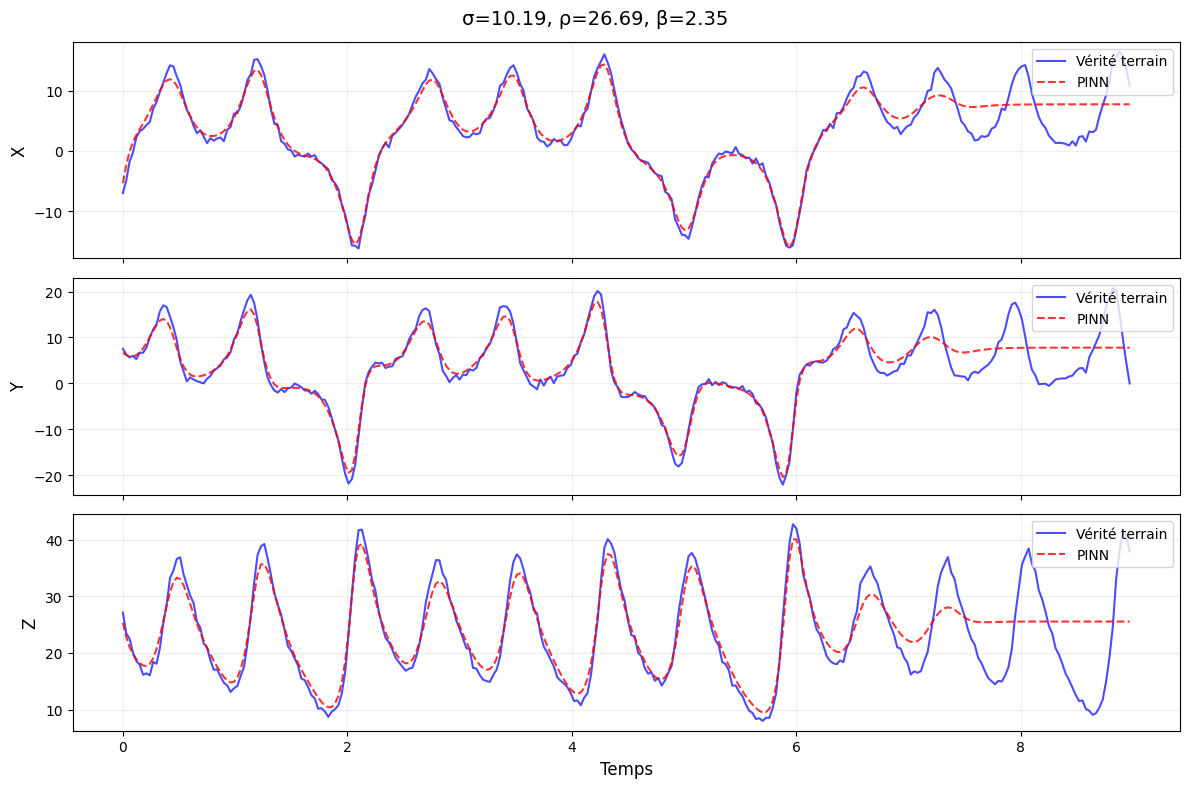

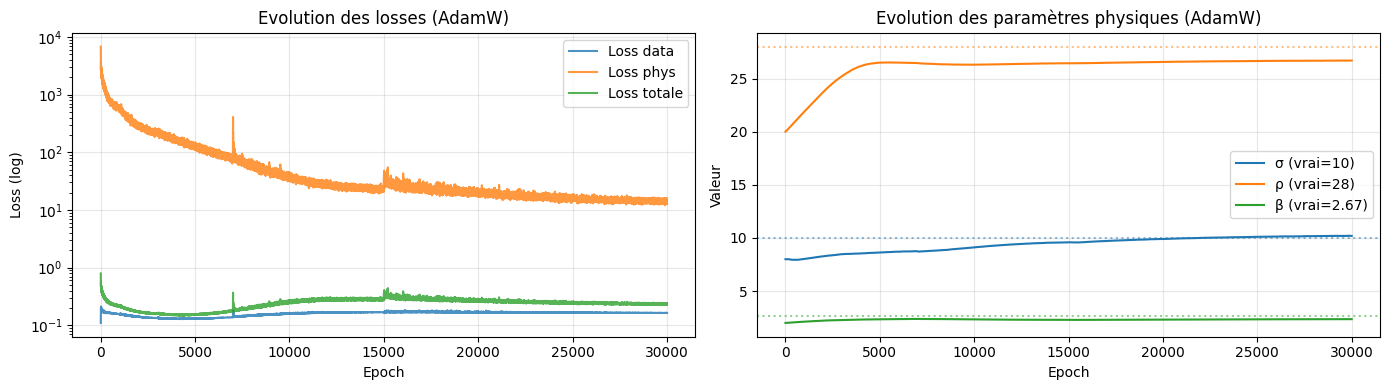

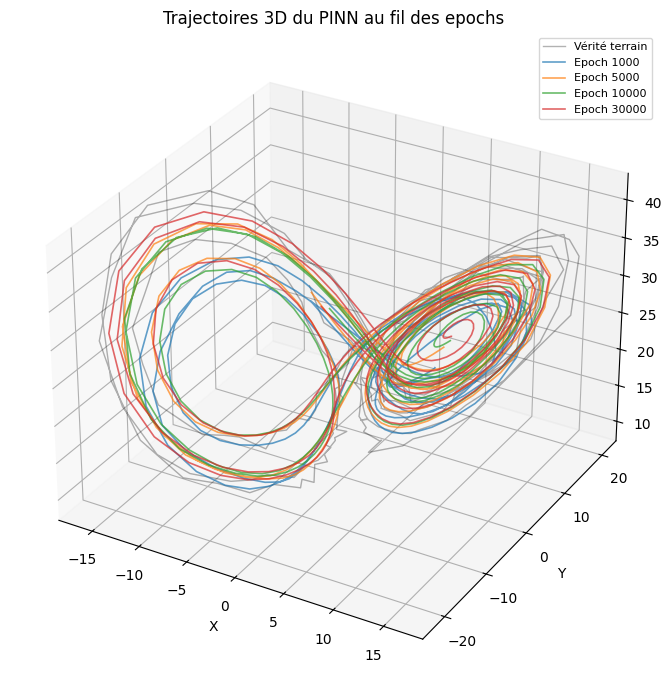

In [5]:
# ==========================================
# 4. Visualisation
# ==========================================
with torch.no_grad():
    X_pred_norm = model(t_tensor).numpy()
    X_pred = X_pred_norm * X_std + X_mean

# --- Trajectoires X, Y, Z ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
labels = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(t_data, X_data[:, i], 'b-', label='Vérité terrain', alpha=0.7, lw=1.5)
    axes[i].plot(t_data, X_pred[:, i], 'r--', label='PINN', alpha=0.8, lw=1.5)
    axes[i].set_ylabel(labels[i], fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.2)
axes[2].set_xlabel('Temps', fontsize=12)
fig.suptitle(f'σ={model.sigma.item():.2f}, ρ={model.rho.item():.2f}, β={model.beta.item():.2f}', fontsize=14)
plt.tight_layout()
plt.show()

# --- Evolution des losses (log scale) ---
if len(epoch_hist) > 0:
    fig_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    ax1.semilogy(epoch_hist, loss_data_hist, label='Loss data', alpha=0.8)
    ax1.semilogy(epoch_hist, loss_phys_hist, label='Loss phys', alpha=0.8)
    ax1.semilogy(epoch_hist, loss_total_hist, label='Loss totale', alpha=0.8)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (log)')
    ax1.set_title('Evolution des losses (AdamW)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Evolution des paramètres
    ax2.plot(epoch_hist, sigma_hist, label=f'σ (vrai=10)', lw=1.5)
    ax2.plot(epoch_hist, rho_hist, label=f'ρ (vrai=28)', lw=1.5)
    ax2.plot(epoch_hist, beta_hist, label=f'β (vrai=2.67)', lw=1.5)
    ax2.axhline(y=10.0, color='C0', ls=':', alpha=0.5)
    ax2.axhline(y=28.0, color='C1', ls=':', alpha=0.5)
    ax2.axhline(y=8/3, color='C2', ls=':', alpha=0.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Valeur')
    ax2.set_title('Evolution des paramètres physiques (AdamW)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Trajectoires 3D à différentes époques ---
if len(snapshots) > 0:
    fig3d = plt.figure(figsize=(10, 7))
    ax3d = fig3d.add_subplot(111, projection='3d')
    ax3d.plot(X_data[:, 0], X_data[:, 1], X_data[:, 2], 'k-', alpha=0.3, lw=1, label='Vérité terrain')
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    for idx, ep in enumerate(sorted(snapshots.keys())):
        traj = snapshots[ep]
        ax3d.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=colors[idx % len(colors)],
                  label=f'Epoch {ep}', alpha=0.7, lw=1.2)
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('Trajectoires 3D du PINN au fil des epochs')
    ax3d.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [6]:
from pathlib import Path
import base64
import json
import numpy as np
import matplotlib.pyplot as plt
import nbformat

out_dir = Path("outputs PINNs") / "t9 noise"
out_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def _save_array(name):
    if name not in globals():
        return
    try:
        arr = np.asarray(globals()[name])
    except Exception:
        return
    if arr.size == 0:
        return
    if arr.ndim <= 1:
        path = out_dir / f"{name}.csv"
        np.savetxt(path, arr.reshape(-1), delimiter=",")
    else:
        path = out_dir / f"{name}.npy"
        np.save(path, arr)
    saved_files.append(str(path))

for var_name in [
    "t_data",
    "X_data",
    "last_pred",
    "epoch_hist",
    "loss_hist",
    "data_loss_hist",
    "physics_loss_hist",
    "sigma_hist",
    "rho_hist",
    "beta_hist",
    "time",
    "X_noisy",
    "X_clean",
]:
    _save_array(var_name)

if "snapshots" in globals() and isinstance(snapshots, dict) and len(snapshots) > 0:
    snap_dir = out_dir / "snapshots"
    snap_dir.mkdir(parents=True, exist_ok=True)
    for ep, traj in snapshots.items():
        p = snap_dir / f"epoch_{ep}.npy"
        np.save(p, np.asarray(traj))
        saved_files.append(str(p))

summary = {
    "sigma_final": float(sigma_hist[-1]) if "sigma_hist" in globals() and len(sigma_hist) > 0 else None,
    "rho_final": float(rho_hist[-1]) if "rho_hist" in globals() and len(rho_hist) > 0 else None,
    "beta_final": float(beta_hist[-1]) if "beta_hist" in globals() and len(beta_hist) > 0 else None,
    "loss_final": float(loss_hist[-1]) if "loss_hist" in globals() and len(loss_hist) > 0 else None,
    "data_loss_final": float(data_loss_hist[-1]) if "data_loss_hist" in globals() and len(data_loss_hist) > 0 else None,
    "physics_loss_final": float(physics_loss_hist[-1]) if "physics_loss_hist" in globals() and len(physics_loss_hist) > 0 else None,
}

summary_path = out_dir / "summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
saved_files.append(str(summary_path))

if "params" in globals():
    params_path = out_dir / "params.txt"
    with open(params_path, "w", encoding="utf-8") as f:
        f.write(str(params))
    saved_files.append(str(params_path))

fig_ids = plt.get_fignums()
for idx, fig_id in enumerate(fig_ids, start=1):
    fig = plt.figure(fig_id)
    fig_path = out_dir / f"figure_{idx:02d}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    saved_files.append(str(fig_path))

notebook_candidates = [Path("pinnV0_t3.ipynb")]
if not notebook_candidates[0].exists():
    notebook_candidates = sorted(Path(".").glob("*t3*.ipynb")) + sorted(Path(".").glob("*.ipynb"))

if len(notebook_candidates) > 0 and notebook_candidates[0].exists():
    nb_path = notebook_candidates[0]
    nb = nbformat.read(nb_path, as_version=4)
    nb_out_dir = out_dir / "notebook_outputs"
    nb_out_dir.mkdir(parents=True, exist_ok=True)

    for cell_idx, cell in enumerate(nb.cells, start=1):
        if cell.get("cell_type") != "code":
            continue
        outputs = cell.get("outputs", [])
        for out_idx, out in enumerate(outputs, start=1):
            if out.get("output_type") == "stream":
                text = out.get("text", "")
                if isinstance(text, list):
                    text = "".join(text)
                p = nb_out_dir / f"cell_{cell_idx:03d}_out_{out_idx:02d}_stream.txt"
                p.write_text(str(text), encoding="utf-8")
                saved_files.append(str(p))
            data = out.get("data", {}) if isinstance(out, dict) else {}
            if "text/plain" in data:
                text = data["text/plain"]
                if isinstance(text, list):
                    text = "".join(text)
                p = nb_out_dir / f"cell_{cell_idx:03d}_out_{out_idx:02d}_text.txt"
                p.write_text(str(text), encoding="utf-8")
                saved_files.append(str(p))
            if "image/png" in data:
                img_b64 = data["image/png"]
                if isinstance(img_b64, list):
                    img_b64 = "".join(img_b64)
                p = nb_out_dir / f"cell_{cell_idx:03d}_out_{out_idx:02d}.png"
                p.write_bytes(base64.b64decode(img_b64))
                saved_files.append(str(p))

manifest_path = out_dir / "saved_outputs_manifest.txt"
with open(manifest_path, "w", encoding="utf-8") as f:
    for p in saved_files:
        f.write(p + "\n")

print(f"Export terminé vers: {out_dir.resolve()}")
print(f"Nombre de fichiers sauvegardés: {len(saved_files)}")
print(f"Manifest: {manifest_path}")

Export terminé vers: C:\Users\gauti\OneDrive\Documents\UE H projet ML\Parameter learning in dynamical systems\PINNs\outputs PINNs\t9 noise
Nombre de fichiers sauvegardés: 21
Manifest: outputs PINNs\t9 noise\saved_outputs_manifest.txt
